In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error

# from xgboost import XGBClassifier, XGBRegressor

In [54]:
amazon = pd.read_csv('ml_ozon_ounterfeit_test_new_features.csv')

In [55]:

print(amazon.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8631 entries, 0 to 8630
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            8631 non-null   int64  
 1   brand_name                    7109 non-null   object 
 2   description                   7463 non-null   object 
 3   name_rus                      8631 non-null   object 
 4   CommercialTypeName4           8631 non-null   object 
 5   rating_1_count                996 non-null    float64
 6   rating_2_count                996 non-null    float64
 7   rating_3_count                996 non-null    float64
 8   rating_4_count                996 non-null    float64
 9   rating_5_count                996 non-null    float64
 10  comments_published_count      996 non-null    float64
 11  photos_published_count        996 non-null    float64
 12  videos_published_count        996 non-null    float64
 13  Pri

In [56]:
amazon = amazon.drop('id',axis=1)
amazon = amazon.drop('ItemID',axis=1)
amazon = amazon.drop('SellerID',axis=1)
amazon = amazon.drop('ItemVarietyCount',axis=1)
amazon = amazon.drop('ItemAvailableCount',axis=1)

for i in range(1,6):
    amazon[f'rating_{i}_count'] = amazon[f'rating_{i}_count'].replace(to_replace = np.nan,value = 0.0)
        
amazon['rating_m_count'] =  (amazon['rating_1_count'] * 1 + amazon['rating_2_count'] * 2 + amazon['rating_3_count'] * 3 + amazon['rating_4_count'] * 4 + amazon['rating_5_count'] * 5) /(amazon['rating_1_count'] + amazon['rating_2_count'] + amazon['rating_3_count'] + amazon['rating_4_count'] + amazon['rating_5_count']  + 1)

for i in range(1,6):
    amazon = amazon.drop(f'rating_{i}_count',axis =1)

amazon['comments_published_count'] =amazon['comments_published_count'].replace(to_replace = np.nan,value = 0.0)
amazon['photos_published_count'] =amazon['photos_published_count'].replace(to_replace = np.nan,value = 0.0)
amazon['videos_published_count'] =amazon['videos_published_count'].replace(to_replace = np.nan,value = 0.0)

amazon['published_count'] = amazon['photos_published_count'] + amazon['comments_published_count'] + amazon['videos_published_count']
amazon = amazon.drop('photos_published_count',axis =1)
amazon = amazon.drop('comments_published_count',axis =1)
amazon = amazon.drop('videos_published_count',axis =1)

amazon['total_count_sell'] = amazon['item_count_sales90']
amazon = amazon.drop('item_count_sales7',axis =1)
amazon = amazon.drop('item_count_sales30',axis =1)
amazon = amazon.drop('item_count_sales90',axis =1)

amazon['total_item_count_fake_return'] = amazon['item_count_fake_returns90']
amazon = amazon.drop('item_count_fake_returns7',axis =1)
amazon = amazon.drop('item_count_fake_returns30',axis =1)
amazon = amazon.drop('item_count_fake_returns90',axis =1)

amazon['total_item_count_return'] = amazon['item_count_returns90']
amazon = amazon.drop('item_count_returns7',axis =1)
amazon = amazon.drop('item_count_returns30',axis =1)
amazon = amazon.drop('item_count_returns90',axis =1)

amazon['total_item_count_real_fake_return'] = amazon['total_item_count_return'] / (amazon['total_item_count_fake_return'] + 1) / 5

amazon = amazon.drop('total_item_count_fake_return',axis =1)
amazon = amazon.drop('total_item_count_return',axis =1)

amazon['total_GmvTotal'] = amazon['GmvTotal90']
amazon = amazon.drop('GmvTotal7',axis =1)
amazon = amazon.drop('GmvTotal30',axis =1)
amazon = amazon.drop('GmvTotal90',axis =1)

amazon['total_ExemplarAC'] = amazon['ExemplarAcceptedCountTotal90']
amazon = amazon.drop('ExemplarAcceptedCountTotal7',axis =1)
amazon = amazon.drop('ExemplarAcceptedCountTotal30',axis =1)
amazon = amazon.drop('ExemplarAcceptedCountTotal90',axis =1)

amazon['total_orader'] = amazon['OrderAcceptedCountTotal90']
amazon = amazon.drop('OrderAcceptedCountTotal7',axis =1)
amazon = amazon.drop('OrderAcceptedCountTotal30',axis =1)
amazon = amazon.drop('OrderAcceptedCountTotal90',axis =1)

amazon['total_ExemplarRC'] = amazon['ExemplarReturnedCountTotal90']
amazon = amazon.drop('ExemplarReturnedCountTotal7',axis =1)
amazon = amazon.drop('ExemplarReturnedCountTotal30',axis =1)
amazon = amazon.drop('ExemplarReturnedCountTotal90',axis =1)

amazon['total_ExemplarRV'] = amazon['ExemplarReturnedValueTotal90']
amazon = amazon.drop('ExemplarReturnedValueTotal7',axis =1)
amazon = amazon.drop('ExemplarReturnedValueTotal30',axis =1)
amazon = amazon.drop('ExemplarReturnedValueTotal90',axis =1)

amazon = amazon.drop('total_orader',axis=1)
amazon = amazon.drop('total_ExemplarRC',axis=1)
amazon = amazon.drop('brand_name',axis=1)
amazon = amazon.drop('description',axis=1)
amazon = amazon.drop('name_rus',axis=1)
amazon = amazon.drop('CommercialTypeName4',axis=1)

amazon['total_item_count_real_fake_return'] = np.where(amazon['total_item_count_real_fake_return'] > 1, 1, amazon['total_item_count_real_fake_return'])

In [57]:
amazon.columns

Index(['PriceDiscounted', 'item_time_alive', 'seller_time_alive',
       'rating_m_count', 'published_count', 'total_count_sell',
       'total_item_count_real_fake_return', 'total_GmvTotal',
       'total_ExemplarAC', 'total_ExemplarRV'],
      dtype='object')

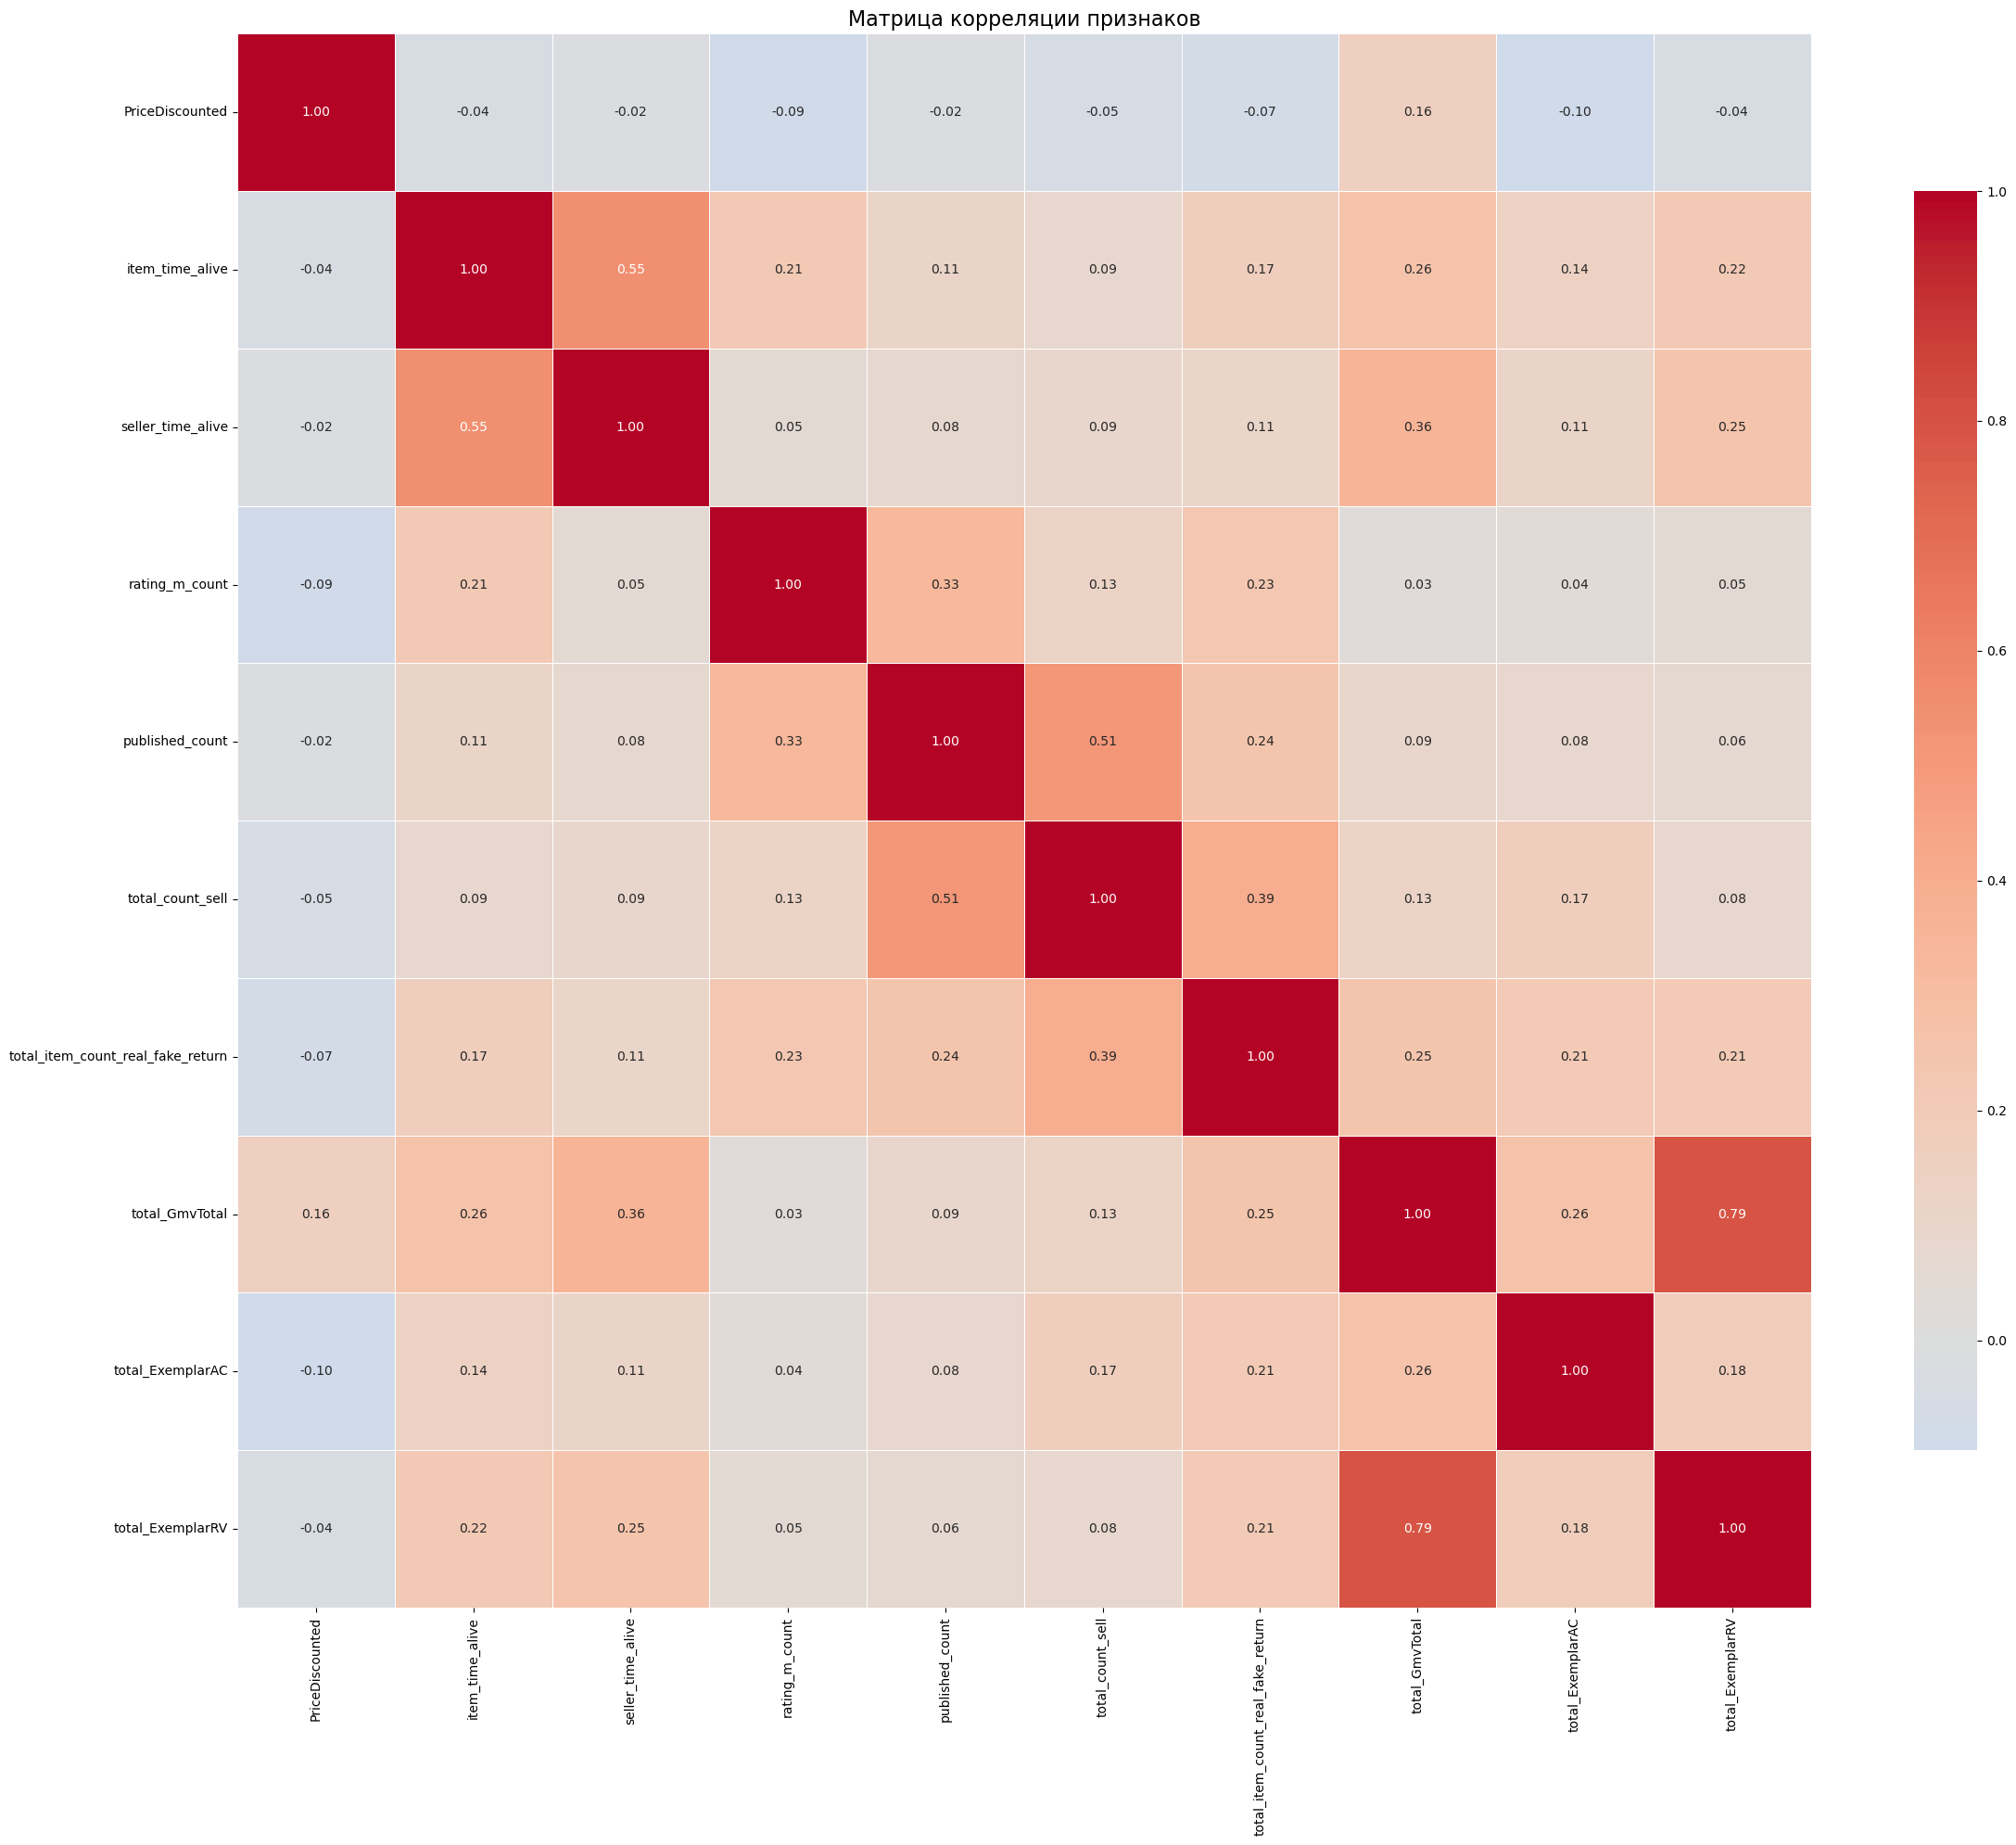

In [58]:
import seaborn as sns


numeric_cols = amazon.select_dtypes(include=[np.number]).columns
amazon_numeric = amazon[numeric_cols]

# 3. Заполняем пропуски (если есть)
# amazon_numeric = amazon_numeric.fillna(0)

# 4. Строим матрицу корреляции
corr_matrix = amazon_numeric.corr()

# 5. Визуализация
plt.figure(figsize=(25, 20))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0, 
            square=True, 
            linewidths=0.5, 
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляции признаков', fontsize=16)
plt.tight_layout()
plt.show()

In [59]:
amazon.describe()

,PriceDiscounted,item_time_alive,seller_time_alive,rating_m_count,published_count,total_count_sell,total_item_count_real_fake_return,total_GmvTotal,total_ExemplarAC,total_ExemplarRV
count,8631.000000,8631.000000,8631.000000,8631.000000,8631.000000,8631.000000,8631.000000,8352.000000,8.352000e+03,8352.000000
mean,821.665377,220.593790,685.514656,0.361338,6.524273,29.457884,0.037568,1486.867216,1.133765e+04,1050.658811
std,213.785430,363.998177,617.615887,1.078619,74.432402,265.890379,0.128711,237.873845,6.255574e+04,425.291276
min,69.629985,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,562.610841,1.000000e+00,0.000000
25%,714.534718,22.000000,161.000000,0.000000,0.000000,0.000000,0.000000,1381.272127,1.730000e+02,1025.325324
50%,828.203078,48.000000,473.000000,0.000000,0.000000,0.000000,0.000000,1511.995307,8.370000e+02,1177.393030
75%,967.708244,254.000000,1109.500000,0.000000,0.000000,1.000000,0.000000,1621.096760,4.379750e+03,1274.820060
max,1449.987598,2313.000000,2443.000000,4.860759,2701.000000,18003.000000,1.000000,2064.980753,1.475890e+06,1724.428434


In [60]:
y = amazon['total_item_count_real_fake_return']
x = amazon.drop('total_item_count_real_fake_return',axis=1)

In [61]:
x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.3,random_state=42,shuffle=True)

In [62]:
df = amazon
df

,PriceDiscounted,item_time_alive,seller_time_alive,rating_m_count,published_count,total_count_sell,total_item_count_real_fake_return,total_GmvTotal,total_ExemplarAC,total_ExemplarRV
0,801.888456,1,5.0,0.000000,0.0,0,0.00,683.851927,1.0,0.000000
1,631.189040,705,1097.0,0.000000,0.0,0,0.00,1545.005524,3490.0,1304.401620
2,787.795317,215,403.0,0.000000,0.0,190,0.44,1768.434979,98515.0,1429.299671
3,650.933679,1162,1807.0,4.314286,39.0,57,0.00,1752.738950,26189.0,1331.699467
4,867.689935,68,232.0,0.000000,0.0,18,0.10,1403.722899,299.0,1269.769138
...,...,...,...,...,...,...,...,...,...,...
8626,704.521985,5,6.0,0.000000,0.0,0,0.00,825.714786,3.0,0.000000
8627,735.104420,5,6.0,0.000000,0.0,0,0.00,825.724141,3.0,0.000000
8628,773.652970,5,6.0,0.000000,0.0,0,0.00,825.699547,3.0,0.000000
8629,697.572309,5,6.0,0.000000,0.0,0,0.00,825.706168,3.0,0.000000


In [63]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns


# 1. Заполняем пропуски (если они есть), например, нулями или медианой
df_clean = df.fillna(0) 

# 2. Масштабирование (Standartization)
# Это приведет все колонки к единому масштабу (среднее=0, стандартное отклонение=1)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Если хотите сохранить названия колонок для удобства:
df_scaled = pd.DataFrame(df_scaled, columns=df_clean.columns)

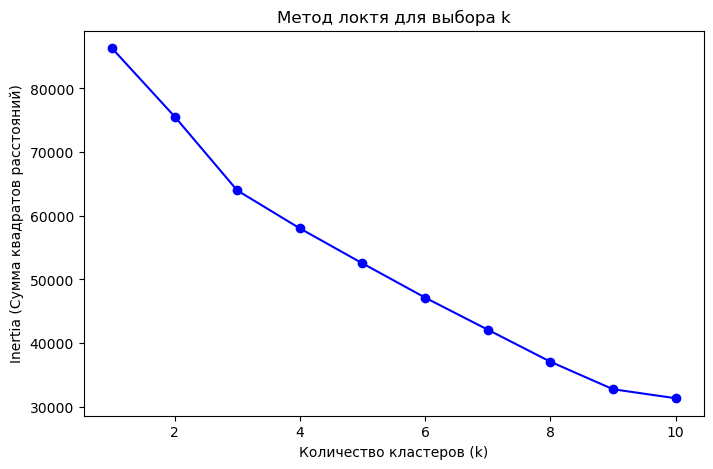

In [64]:
from sklearn.cluster import KMeans

# Считаем сумму квадратов расстояний (inertia) для разного числа кластеров (от 1 до 10)
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Рисуем график
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Inertia (Сумма квадратов расстояний)')
plt.title('Метод локтя для выбора k')
plt.show()

In [65]:
# Задаем выбранное количество кластеров
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(df_scaled)

# Добавляем номер кластера в ИСХОДНЫЙ датафрейм
df['Cluster'] = clusters

print(df['Cluster'].value_counts()) # Посмотрим, сколько товаров попало в каждый кластер

Cluster
1    5490
2    1363
0    1096
3     682
Name: count, dtype: int64


In [66]:
# Смотрим средние показатели по каждому кластеру
cluster_analysis = df.groupby('Cluster').mean().round(2)
display(cluster_analysis)

,PriceDiscounted,item_time_alive,seller_time_alive,rating_m_count,published_count,total_count_sell,total_item_count_real_fake_return,total_GmvTotal,total_ExemplarAC,total_ExemplarRV
Cluster,,,,,,,,,,
0,803.46,788.16,1516.88,0.08,0.59,114.64,0.14,1708.85,54984.37,1353.97
1,823.42,91.16,563.29,0.06,0.06,7.20,0.01,1513.22,4674.22,1170.34
2,860.09,155.41,442.20,0.14,0.32,0.19,0.00,1106.18,41.09,67.52
3,760.00,480.65,819.64,3.72,80.51,130.22,0.14,1523.69,12809.29,1164.07


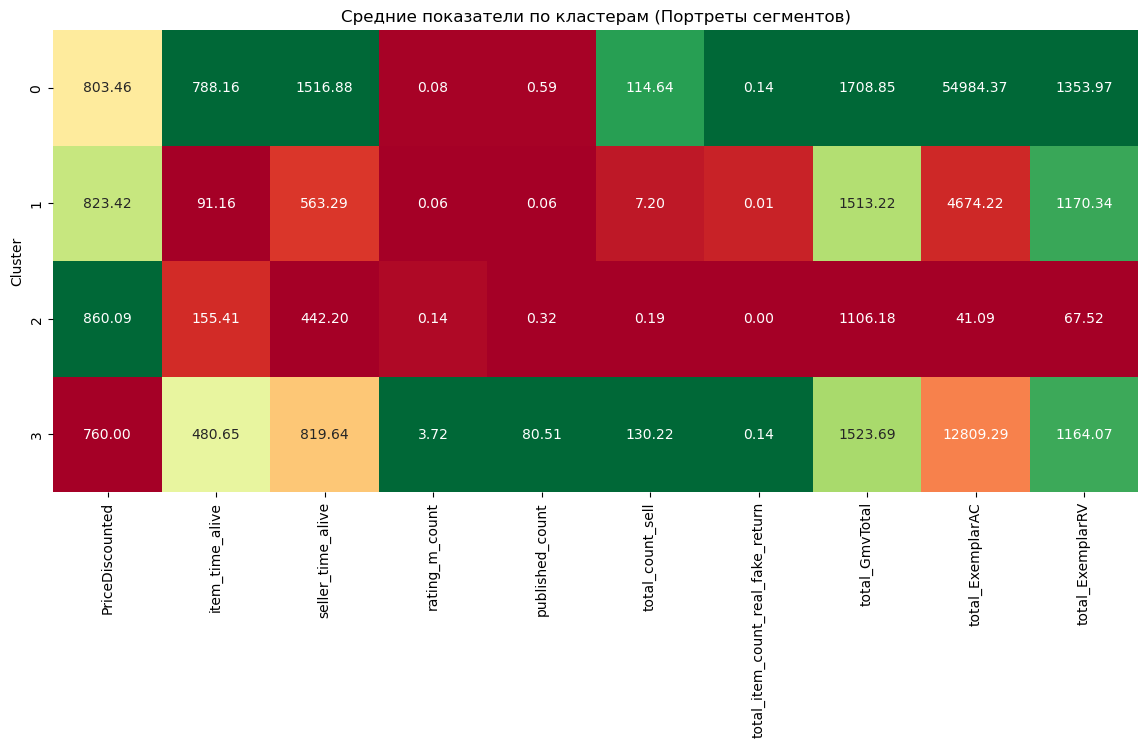

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Нормализуем данные ТОЛЬКО для графика (чтобы цвета были сравнимы), 
# но подписи оставим реальными (annot=cluster_analysis)
scaler = MinMaxScaler()
cluster_analysis_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_analysis), 
    columns=cluster_analysis.columns, 
    index=cluster_analysis.index
)

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_analysis_scaled, annot=cluster_analysis, fmt=".2f", cmap="RdYlGn", cbar=False)
plt.title("Средние показатели по кластерам (Портреты сегментов)")
plt.show()

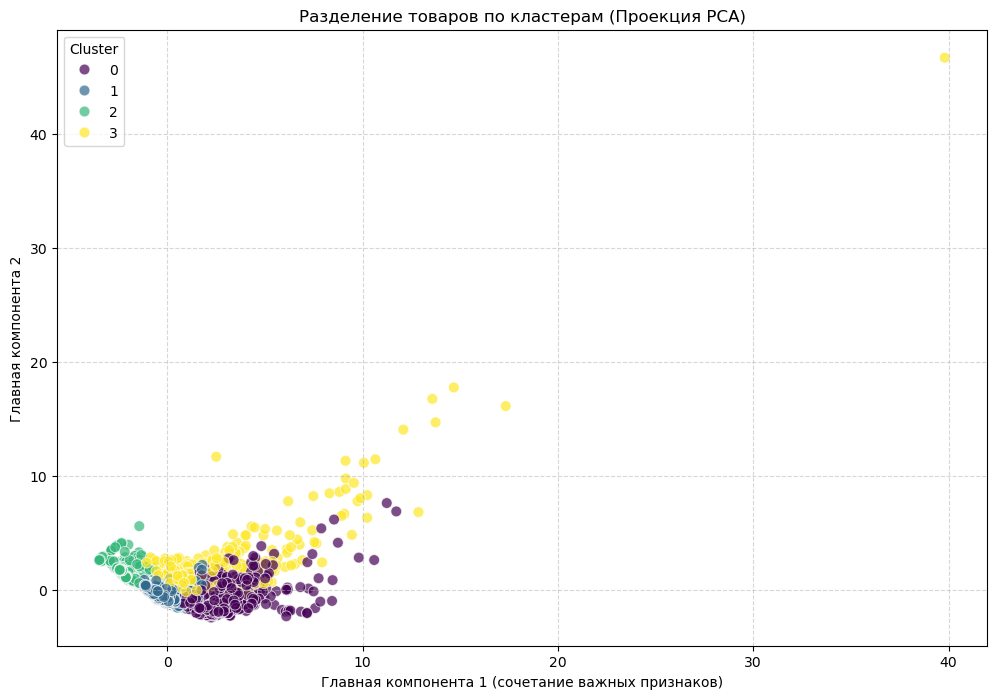

In [68]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Сжимаем 10 признаков до 2-х координат (x и y)
pca = PCA(n_components=2)
components = pca.fit_transform(df_scaled) # df_scaled — нормализованные данные

# 2. Создаем временный DataFrame для отрисовки
df_plot = pd.DataFrame(data=components, columns=['x', 'y'])
df_plot['Cluster'] = clusters # наши результаты кластеризации

# 3. Рисуем "точки на полотне"
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='x', y='y', 
    hue='Cluster', 
    data=df_plot, 
    palette='viridis', 
    alpha=0.7, 
    edgecolor='w', 
    s=60 # размер точек
)

plt.title('Разделение товаров по кластерам (Проекция PCA)')
plt.xlabel('Главная компонента 1 (сочетание важных признаков)')
plt.ylabel('Главная компонента 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [69]:
from sklearn.cluster import DBSCAN

# eps - радиус поиска соседей, min_samples - минимум точек для создания кластера
dbscan = DBSCAN(eps=0.5, min_samples=5) 
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)

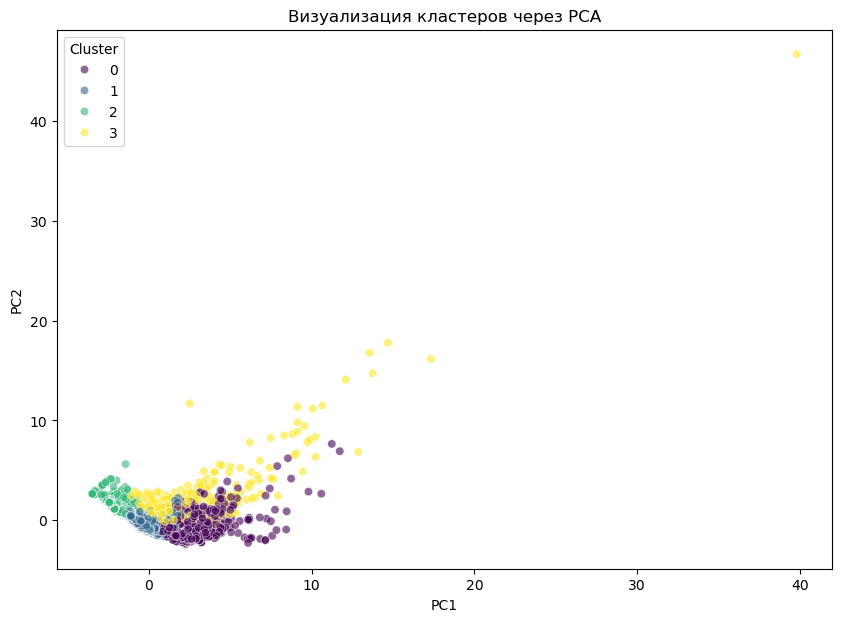

In [70]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Сокращаем размерность до 2 компонент
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled) # используем отмасштабированные данные из прошлого шага

# 2. Создаем таблицу для визуализации
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = clusters # добавляем номера кластеров

# 3. Рисуем график
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.6)
plt.title('Визуализация кластеров через PCA')
plt.show()

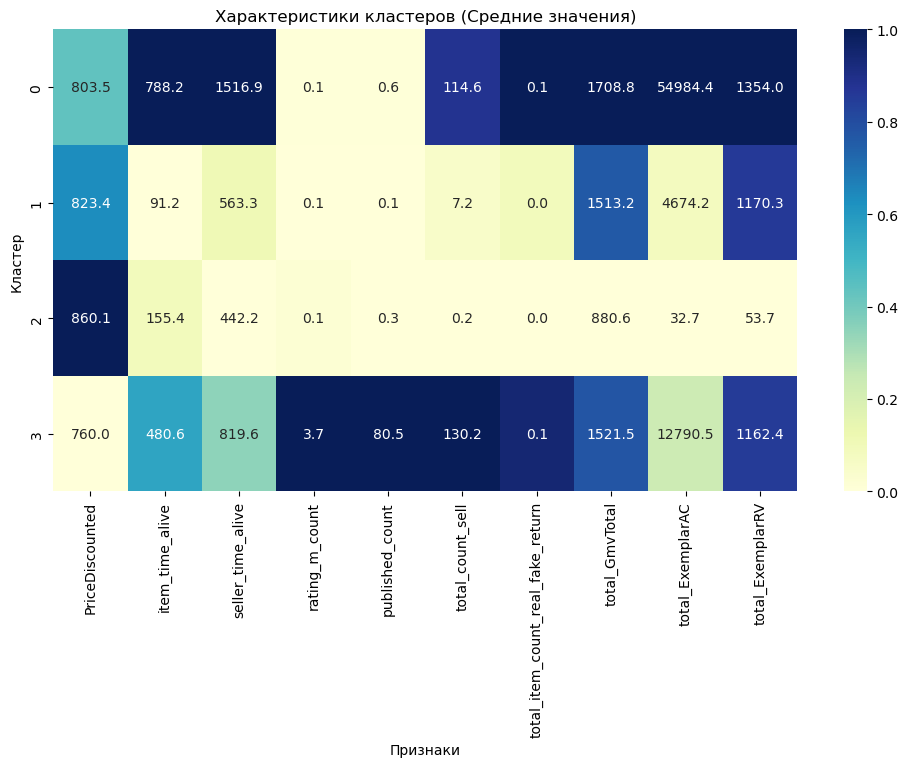

In [71]:
# Считаем среднее для каждого признака в каждом кластере
# Чтобы цифры были понятными, используем исходный масштаб (df_clean), а не нормализованный
cluster_centers = df_clean.groupby(clusters).mean()

# Нормализуем для красоты отображения в heatmap (от 0 до 1), чтобы масштаб не сбивал цвета
cluster_centers_scaled = (cluster_centers - cluster_centers.min()) / (cluster_centers.max() - cluster_centers.min())

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_centers_scaled, annot=cluster_centers, fmt=".1f", cmap="YlGnBu")
plt.title('Характеристики кластеров (Средние значения)')
plt.xlabel('Признаки')
plt.ylabel('Кластер')
plt.show()

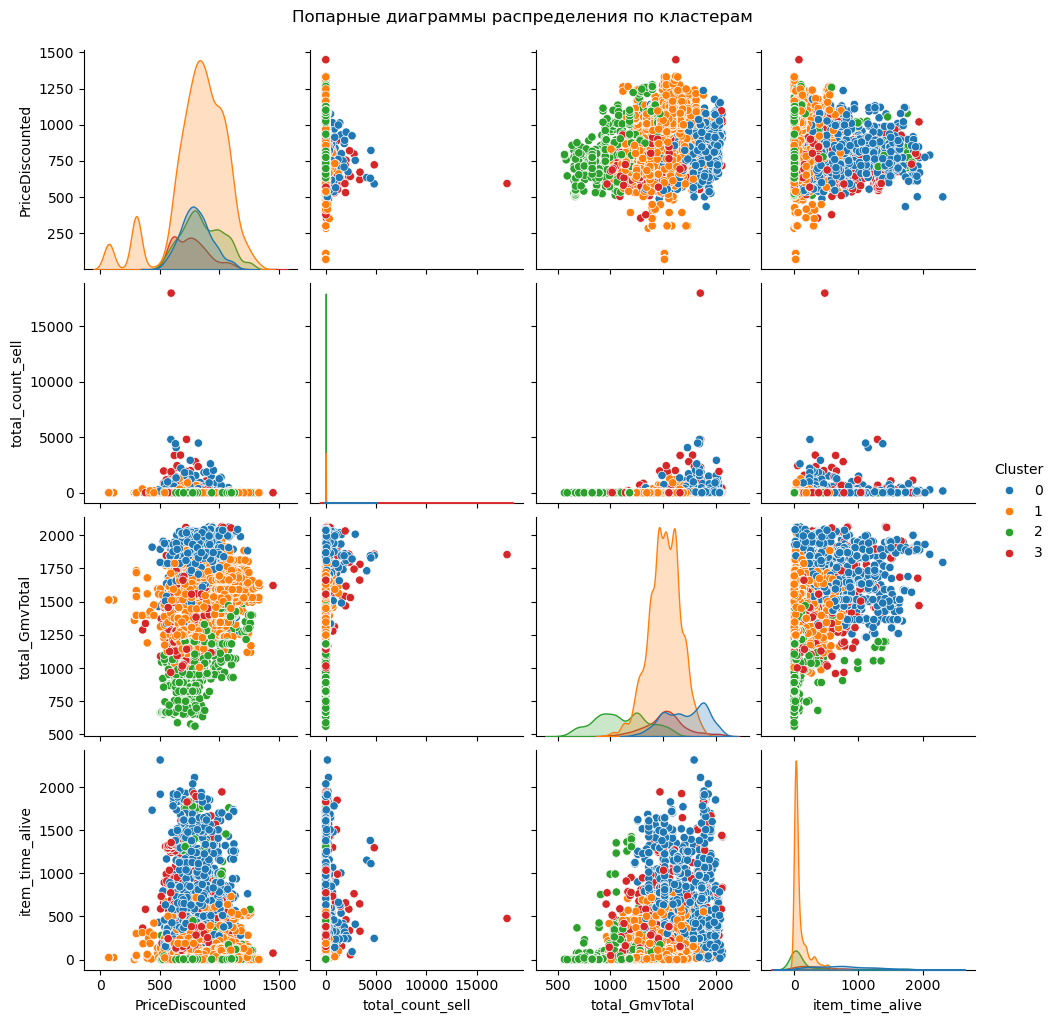

In [72]:
# Выбираем 3-4 самых важных столбца для визуализации
features_to_plot = ['PriceDiscounted', 'total_count_sell', 'total_GmvTotal', 'item_time_alive']

sns.pairplot(df[features_to_plot + ['Cluster']], hue='Cluster', palette='tab10', diag_kind='kde')
plt.suptitle('Попарные диаграммы распределения по кластерам', y=1.02)
plt.show()